# Simulación de Medición Cuántica con Qiskit

## Objetivo de la clase

Comprender el fenómeno de medición en mecánica cuántica mediante la simulación de qubits en estados puros y superpuestos. Usaremos Qiskit para observar histogramas de resultados, comparar frecuencias relativas con probabilidades teóricas y visualizar el colapso del estado cuántico.

---

## Contenidos

1. Medición en sistemas cuánticos
2. Estados puros vs. estados superpuestos
3. Simulación de circuitos cuánticos con Qiskit
4. Histograma de mediciones y comparación con la teoría
5. Observación del colapso cuántico

---

### 🔹 Introducción

En la computación clásica, medir un bit significa **leer su valor**: 0 o 1.  
En computación cuántica, **medir un qubit** es un proceso fundamentalmente diferente: es un fenómeno **probabilístico**, **irreversible** y con implicaciones físicas profundas.

---

### 🔹 El estado de un qubit

Un qubit puede estar en una **superposición** de los estados base |0⟩ y |1⟩:

$$
|\psi\rangle = \alpha |0\rangle + \beta |1\rangle
$$

Donde:
- $ \alpha, \beta \in \mathbb{C} $ (números complejos)
- $ |\alpha|^2 + |\beta|^2 = 1 $ (normalización)

🔸 Ejemplos:
- $ |\psi\rangle = \frac{1}{\sqrt{2}}(|0\rangle + |1\rangle) $
- $ |\psi\rangle = \frac{1}{\sqrt{2}}(|0\rangle - |1\rangle) $
- $ |\psi\rangle = \frac{1}{\sqrt{2}}(|0\rangle + i|1\rangle) $

---

### 🔹 Medición en la base computacional

Cuando medimos un qubit, colapsamos su estado a uno de los estados base del sistema.

En Qiskit (y en la mayoría de los casos), usamos la **base computacional**, es decir, la base ortonormal:

$$
\mathcal{B} = \{ |0\rangle, |1\rangle \}
$$

**Resultado de la medición:**

- Se obtiene el resultado `0` con probabilidad $ |\alpha|^2 $
- Se obtiene el resultado `1` con probabilidad $ |\beta|^2 $

Y **el estado del qubit colapsa** al estado correspondiente.

---

### 🔹 Ejemplo matemático

Si el qubit está en el estado:

$$
|\psi\rangle = \frac{1}{\sqrt{3}}|0\rangle + \sqrt{\frac{2}{3}}|1\rangle
$$

Entonces:

- Probabilidad de obtener `0`: $ \left|\frac{1}{\sqrt{3}}\right|^2 = \frac{1}{3} $
- Probabilidad de obtener `1`: $ \left|\sqrt{\frac{2}{3}}\right|^2 = \frac{2}{3} $

➡️ Si se mide y el resultado es `1`, el nuevo estado del qubit será:

$
|\psi'\rangle = |1\rangle
$

La superposición **se destruye**.  
El qubit **colapsa** a un estado.

---

### 🔹 ¿Qué significa colapso?

El colapso es un fenómeno físico según el cual, tras la medición, el sistema **ya no está en superposición**, sino que se comporta como un sistema clásico.

Antes de medir:
$$
|\psi\rangle = \frac{1}{\sqrt{2}}(|0\rangle + |1\rangle)
$$

Después de medir (y obtener `0`):
$$
|\psi\rangle = |0\rangle
$$

➡️ Ya no hay posibilidad de que esté en `1`, salvo que se vuelva a aplicar alguna puerta cuántica.

---


## 🔹 Resume: ¿Qué es una medición cuántica?

- En mecánica cuántica, medir un qubit cambia su estado.
- La medición **colapsa el estado cuántico** a uno de los estados base (por ejemplo, |0⟩ o |1⟩).
- El resultado individual es aleatorio, pero tiene una **probabilidad definida** por el estado del qubit.

---

## 🔹 Estados cuánticos

### Estados puros
- |0⟩ → estado base
- |1⟩ → excitado

### Estados superpuestos
- |+⟩ = (|0⟩ + |1⟩)/√2
- |-⟩ = (|0⟩ - |1⟩)/√2
- (|0⟩ + i|1⟩)/√2 → estado con fase

Estos estados no tienen un valor definido al medirse, sino una **distribución de probabilidad**.

---

## Simulación en Qiskit

### Backend de simulación
Usamos `Aer` y `qasm_simulator` para obtener estadísticas de medición.

### Proceso general:
1. Crear un circuito cuántico
2. Preparar el estado deseado
3. Medir el qubit
4. Ejecutar múltiples veces (`shots`)
5. Visualizar resultados (histograma)

---

## Ejemplos prácticos

1. Medición en estado |0⟩ → siempre da '0'
2. Medición en |+⟩ → ~50% '0', ~50% '1'
3. Medición en |-⟩ → similar a |+⟩ (en base computacional)
4. Medición en (|0⟩ + i|1⟩)/√2 → resultado aleatorio, fase no afecta directamente

---

## Frecuencias relativas vs. probabilidades

- Las **probabilidades teóricas** son las esperadas por el estado.
- Las **frecuencias relativas** son lo que se observa en la simulación.
- A medida que aumentan los `shots`, las frecuencias relativas convergen a las probabilidades teóricas.

---

## Actividad práctica

### Construir y medir los siguientes estados:

1. **|0⟩**  
   - Esperado: 100% '0'

2. **|+⟩ = (|0⟩ + |1⟩)/√2**  
   - Usa puerta `H`  
   - Esperado: ~50% '0', ~50% '1'

3. **|1⟩**  
   - Usa puerta `X`  
   - Esperado: 100% '1'

4. **( |0⟩ + i|1⟩ ) / √2**  
   - Usa `H` + `S`  
   - Esperado: ~50% '0', ~50% '1'

5. **Repetir medición con 1 shot**  
   - Observar el **colapso** cuántico

6. **Comparar frecuencias relativas con probabilidades**  
   - Variar `shots`: 10, 100, 1000, 10000  
   - Graficar convergencia

---

### 🔹 Repetibilidad y shots

No podemos medir el mismo qubit varias veces **porque se colapsa al primer intento**.  
Lo que hacemos es **preparar el mismo circuito muchas veces** y medir una vez por ejecución.

Esto se llama usar **“shots”** (disparos).

Por ejemplo:

result = execute(circuit, backend, shots=1000).result()

In [1]:
from qiskit import QuantumCircuit
from qiskit_aer.primitives import SamplerV2 as Sampler
from qiskit_aer import AerSimulator
from qiskit.transpiler import generate_preset_pass_manager
from qiskit.visualization import plot_histogram
import numpy as np

Estado |0⟩: {'0': 1024}


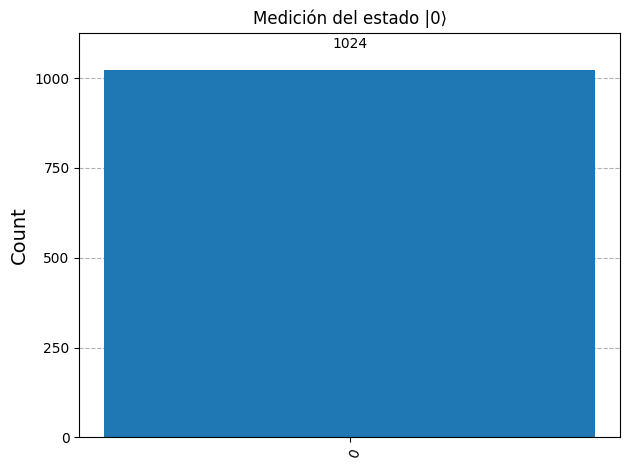

In [2]:
# Estado 1

qc = QuantumCircuit(1, 1)
qc.measure(0, 0)

# Hace una copia del circuito qc para no modificar el original.
measured_circuit = qc.copy()

# Agrega una medición a todos los qubits del circuito. En Qiskit, las mediciones no se agregan automáticamente.
# Esta línea garantiza que todos los qubits se midan y que los resultados puedan ser leídos
measured_circuit.measure_all()

# Prepara una lista de valores de parámetros.
# Algunos circuitos en Qiskit pueden tener parámetros simbólicos (por ejemplo, theta, phi,
params = []

# Crea un Sampler (versión nueva de Qiskit) usando el simulador Aer con el método "stabilizer".
# El Sampler es una primitiva que toma un circuito y devuelve probabilidades de medición.
# "stabilizer" es un método muy rápido que funciona bien cuando solo usas puertas tipo Clifford X, H, S, CNOT.

# En el contexto de Qiskit, una primitiva (o primitive) es un componente básico de ejecución cuántica,
# pensado para ofrecer una interfaz más simple, modular y eficiente para tareas
exact_sampler = Sampler(options={"backend_options": {"method": "stabilizer"}})

# Crea un optimizador (transpilador) que adapta tu circuito al simulador.
# El "pass manager" optimiza y convierte tu circuito en una forma compatible con el backend.
# El número 1 indica el nivel de optimización (puede ir de 0 a 3).
pass_manager = generate_preset_pass_manager(1, AerSimulator(method="stabilizer"))

# Transpila tu circuito para que sea ejecutable en el simulador.
# isa_circuit es el circuito ya optimizado y adaptado al backend (AerSimulator).
# Es lo que finalmente se va a ejecutar.
isa_circuit = pass_manager.run(measured_circuit)

# Empaqueta el circuito y los parámetros en una tupla para pasarlos al Sampler
# Este es el formato que Sampler.run() espera: una lista de pares (circuito, parámetros).
pub = (isa_circuit, params)

# Ejecuta el circuito usando el Sampler.
# Se puede pasar una lista de circuitos parametrizados, aquí solo hay uno.
job = exact_sampler.run([pub])

# Espera a que termine la ejecución y obtiene el resultado completo.
result = job.result()

# Extrae el conteo de resultados de medición.
# result[0] accede al primer resultado (hay uno solo en este caso).
# .data.meas.get_counts() obtiene un diccionario con las mediciones
counts = result[0].data.meas.get_counts()
print("Estado |0⟩:", counts)

plot_histogram(counts, title="Medición del estado |0⟩")
# qc.draw('mpl')

Estado |0⟩: {'1': 508, '0': 516}


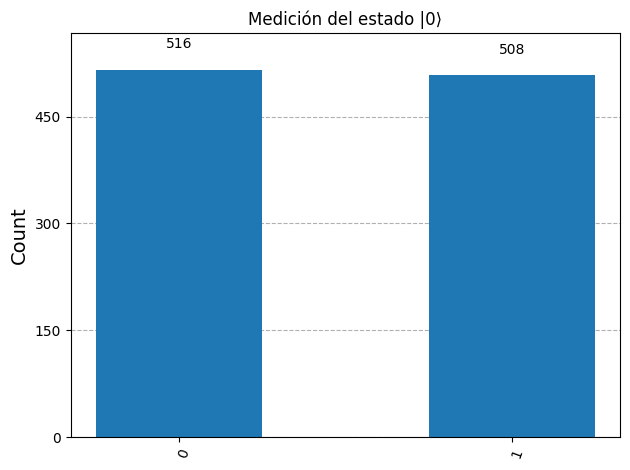

In [ ]:
qc = QuantumCircuit(1, 1)
qc.h(0)
qc.measure(0, 0)
measured_circuit = qc.copy()
measured_circuit.measure_all()
params = []
exact_sampler = Sampler(options={"backend_options": {"method": "stabilizer"}})
pass_manager = generate_preset_pass_manager(1, AerSimulator(method="stabilizer"))
isa_circuit = pass_manager.run(measured_circuit)
pub = (isa_circuit, params)
job = exact_sampler.run([pub])
result = job.result()
# counts = result[0].data.meas.get_counts()
print("Estado |+⟩:", counts)
plot_histogram(counts, title="Medición del estado |+⟩")

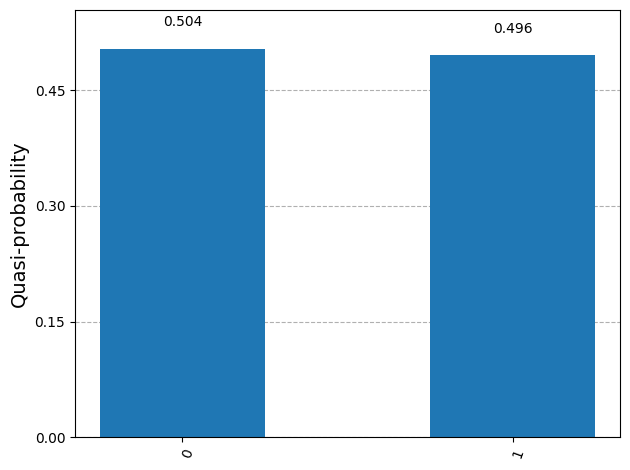

In [14]:
# Normalizacion
total_shots = sum(counts.values())
normalized_counts = {key: val / total_shots for key, val in counts.items()}

plot_histogram(normalized_counts)

Estado |1⟩: {'1': 1024}


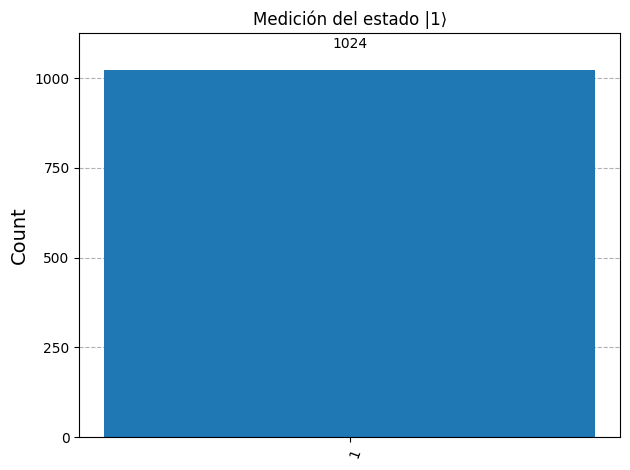

In [17]:
# Estado 3
qc = QuantumCircuit(1, 1)
qc.x(0)
qc.measure(0, 0)
measured_circuit = qc.copy()
measured_circuit.measure_all()
params = []
exact_sampler = Sampler(options={"backend_options": {"method": "stabilizer"}})
pass_manager = generate_preset_pass_manager(1, AerSimulator(method="stabilizer"))
isa_circuit = pass_manager.run(measured_circuit)
pub = (isa_circuit, params)
job = exact_sampler.run([pub])
result = job.result()
counts = result[0].data.meas.get_counts()
print("Estado |1⟩:", counts)
plot_histogram(counts, title="Medición del estado |1⟩")

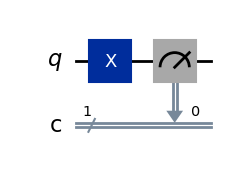

In [19]:
qc.draw(output="mpl")

Estado |+⟩: {'0': 532, '1': 492}


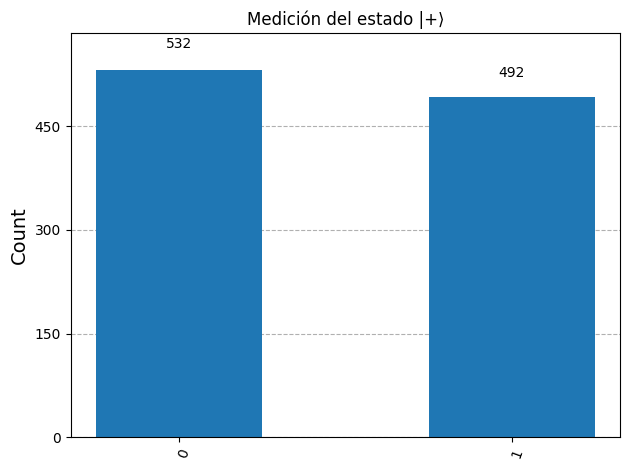

In [21]:
# Estado 4
qc = QuantumCircuit(1, 1)
qc.h(0)
qc.s(0)
qc.measure(0, 0)
measured_circuit = qc.copy()
measured_circuit.measure_all()
params = []
exact_sampler = Sampler(options={"backend_options": {"method": "stabilizer"}})
pass_manager = generate_preset_pass_manager(1, AerSimulator(method="stabilizer"))
isa_circuit = pass_manager.run(measured_circuit)
pub = (isa_circuit, params)
job = exact_sampler.run([pub])
result = job.result()
counts = result[0].data.meas.get_counts()
print("Estado |+⟩:", counts)
plot_histogram(counts, title="Medición del estado |+⟩")

{'0': 1}


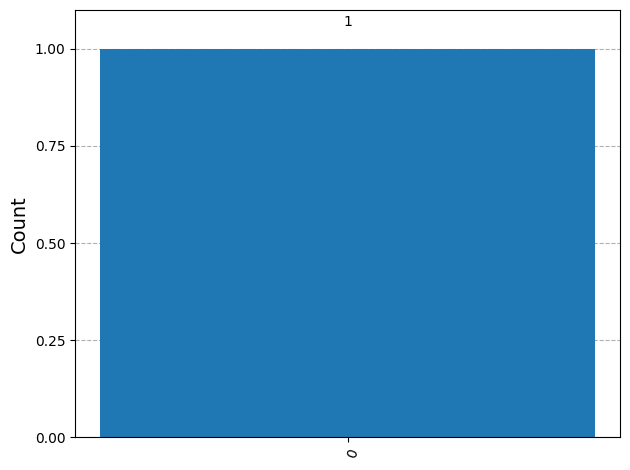

In [24]:
from qiskit.circuit import Parameter

theta = Parameter("theta")
qc = QuantumCircuit(1, 1)
qc.rz(theta, 0)
qc.measure(0, 0)

measured_circuit = qc.copy()
measured_circuit.measure_all()

rng = np.random.default_rng(1234)
params = [rng.choice([0, np.pi / 2, np.pi, 3 * np.pi / 2])]
exact_sampler = Sampler(options={"backend_options": {"method": "stabilizer"}})
pass_manager = generate_preset_pass_manager(1, AerSimulator(method="stabilizer"))
isa_circuit = pass_manager.run(measured_circuit)

pub = (isa_circuit, params)
job = exact_sampler.run([pub], shots=1)
result = job.result()
counts = result[0].data.meas.get_counts()

print(counts)
plot_histogram(counts)

In [ ]:
# task 5

In [31]:
# task 6
shots = 10000
qc = QuantumCircuit(1, 1)
qc.h(0)
qc.measure(0, 0)
measured_circuit = qc.copy()
measured_circuit.measure_all()
params = []
exact_sampler = Sampler(options={"backend_options": {"method": "stabilizer"}})
pass_manager = generate_preset_pass_manager(1, AerSimulator(method="stabilizer"))
isa_circuit = pass_manager.run(measured_circuit)
pub = (isa_circuit, params)
job = exact_sampler.run([pub], shots=shots)
result = job.result()
counts = result[0].data.meas.get_counts()
print(f"Shots = {shots} -->", counts)

Shots = 10000 --> {'1': 5006, '0': 4994}


# Estados de Bell – Entrelazamiento Cuántico de 2 Qubits

Los **estados de Bell** son los ejemplos más conocidos de **estados cuánticos entrelazados** de dos qubits.

## ¿Qué es el entrelazamiento?

Dos qubits están **entrelazados** cuando el estado de uno **no puede describirse de forma independiente** del otro.

- Si mides uno, el otro se colapsa instantáneamente, incluso a distancia.
- Esta es una propiedad **puramente cuántica**, sin análogo clásico.

---

## 🎯 Estados de Bell – Definición

Los **cuatro estados de Bell** forman una **base ortonormal** para el espacio de 2 qubits. Se definen como:

### ✅ Notación matemática:

\[
\begin{align*}
|\Phi^+\rangle &= \frac{1}{\sqrt{2}} (|00\rangle + |11\rangle) \\
|\Phi^-\rangle &= \frac{1}{\sqrt{2}} (|00\rangle - |11\rangle) \\
|\Psi^+\rangle &= \frac{1}{\sqrt{2}} (|01\rangle + |10\rangle) \\
|\Psi^-\rangle &= \frac{1}{\sqrt{2}} (|01\rangle - |10\rangle)
\end{align*}
\]

---

## ⚙️ Cómo construirlos en circuitos cuánticos

### ▶️ Estado `|Φ⁺⟩ = (|00⟩ + |11⟩)/√2`

```python
from qiskit import QuantumCircuit
qc = QuantumCircuit(2, 2)
qc.h(0)
qc.cx(0, 1)
qc.measure([0, 1], [0, 1])
qc.draw("mpl")


Estados de Bell {'11': 500133, '00': 499867}


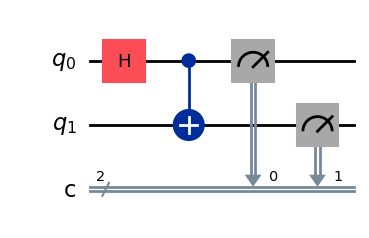

In [ ]:
# |Φ⁺⟩ = (|00⟩ + |11⟩)/√2
from qiskit import QuantumCircuit

qc = QuantumCircuit(2, 2)
qc.h(0)
qc.cx(0, 1)
qc.measure([0, 1], [0, 1])
measured_circuit = qc.copy()
measured_circuit.measure_all()
params = []
exact_sampler = Sampler(options={"backend_options": {"method": "stabilizer"}})
pass_manager = generate_preset_pass_manager(1, AerSimulator(method="stabilizer"))
isa_circuit = pass_manager.run(measured_circuit)
pub = (isa_circuit, params)
job = exact_sampler.run([pub], shots=1000)
result = job.result()
counts = result[0].data.meas.get_counts()
plot_histogram(counts)
print("Estados de Bell", counts)
qc.draw("mpl")

Estados de Bell - :  {'00': 4962, '11': 5038}


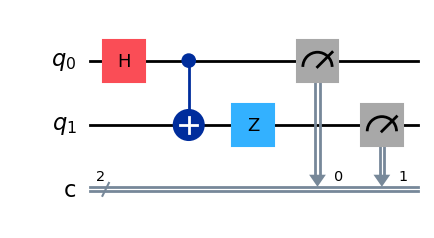

In [47]:
# "Bell state |Φ⁻⟩ = (|00⟩ − |11⟩)/√2"

qc = QuantumCircuit(2, 2)
qc.h(0)
qc.cx(0, 1)
qc.z(1)

qc.measure([0, 1], [0, 1])
measured_circuit = qc.copy()
measured_circuit.measure_all()
params = []
exact_sampler = Sampler(options={"backend_options": {"method": "stabilizer"}})
pass_manager = generate_preset_pass_manager(1, AerSimulator(method="stabilizer"))
isa_circuit = pass_manager.run(measured_circuit)
pub = (isa_circuit, params)
job = exact_sampler.run([pub], shots=10000)
result = job.result()
counts = result[0].data.meas.get_counts()
plot_histogram(counts)
print("Estados de Bell - : ", counts)
qc.draw("mpl")

Estados de Bell psi + :  {'10': 4992, '01': 5008}


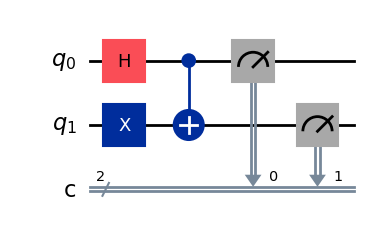

In [51]:
# "Bell state |Ψ⁺⟩ = (|01⟩ + |10⟩)/√2"

qc = QuantumCircuit(2, 2)
qc.h(0)
qc.x(1)
qc.cx(0, 1)

qc.measure([0, 1], [0, 1])

measured_circuit = qc.copy()
measured_circuit.measure_all()
params = []
exact_sampler = Sampler(options={"backend_options": {"method": "stabilizer"}})
pass_manager = generate_preset_pass_manager(1, AerSimulator(method="stabilizer"))
isa_circuit = pass_manager.run(measured_circuit)
pub = (isa_circuit, params)
job = exact_sampler.run([pub], shots=10000)
result = job.result()
counts = result[0].data.meas.get_counts()
plot_histogram(counts)
print("Estados de Bell psi + : ", counts)
qc.draw("mpl")

Estados de Bell psi -:  {'01': 4953, '10': 5047}


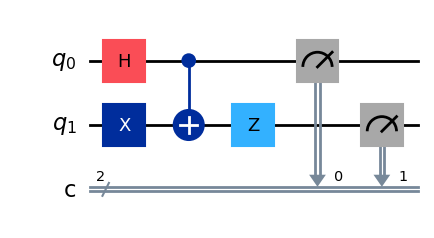

In [55]:
# "Bell state |Ψ⁻⟩ = (|01⟩ − |10⟩)/√2"

qc = QuantumCircuit(2, 2)
qc.x(1)
qc.h(0)
qc.cx(0, 1)
qc.z(1)

qc.measure([0, 1], [0, 1])

measured_circuit = qc.copy()
measured_circuit.measure_all()
params = []
exact_sampler = Sampler(options={"backend_options": {"method": "stabilizer"}})
pass_manager = generate_preset_pass_manager(1, AerSimulator(method="stabilizer"))
isa_circuit = pass_manager.run(measured_circuit)
pub = (isa_circuit, params)
job = exact_sampler.run([pub], shots=10000)
result = job.result()
counts = result[0].data.meas.get_counts()
plot_histogram(counts)
print("Estados de Bell psi -: ", counts)
qc.draw("mpl")

###  Qiskit tiene dos formas principales de ejecutar circuitos cuánticos:

#### 1. Simulación local (sin internet)

Puedes ejecutar circuitos cuánticos en tu propia máquina, **sin necesidad de conexión a IBM Quantum**, usando el módulo `qiskit-aer`.

- No necesitas cuenta.
- Corre rápido en CPU (o GPU si está habilitado).
- Ejemplo de uso:

```python
from qiskit_aer import AerSimulator

sim = AerSimulator()
result = sim.run(circuit).result()


### 2. Ejecución en hardware real (requiere cuenta de IBM Quantum)

Si quieres ejecutar el circuito en una **computadora cuántica real** (o en un **simulador en la nube**), necesitas:

1. Crear una cuenta en [IBM Quantum](https://quantum-computing.ibm.com/)
2. Obtener un **token de acceso**
3. Guardar tu cuenta y conectarte desde Qiskit

Este método requiere conexión a internet y permite acceso a:
- Hardware cuántico real (como ibmq_manila, ibmq_jakarta, etc.)
- Simuladores de alto rendimiento en la nube
- "Runtime primitives" como Sampler y Estimator (más eficientes para tareas específicas)

#### Conexión usando `IBMProvider`:

```python
from qiskit_ibm_provider import IBMProvider

provider = IBMProvider(token='TU_TOKEN')
backend = provider.get_backend('ibmq_qasm_simulator')


## Recursos útiles

- [Qiskit Documentation](https://qiskit.org/documentation/)
- [IBM Quantum Composer](https://quantum-computing.ibm.com/)
- [Qiskit Textbook (en inglés)](https://qiskit.org/textbook)